# VizWiz-VQA using SigLIP feature extractors

## Installing Required Libraries

In [1]:
!pip install -qq ftfy
!pip install -qq Levenshtein
!pip install -q git+https://github.com/mlfoundations/open_clip.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.4 MB/s eta 0:00:00:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.1 MB/s eta 0:00:0000:01:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━

## Importing Required Libraries

In [2]:
# Importing OS for system operations, numpy and pandas for data manipulation
import os
import numpy as np 
import pandas as pd
import math

# Importing tqdm to track computation progress
from tqdm.notebook import tqdm
# Importing tabulate for printing formatted results table
from tabulate import tabulate

# For data visualization, we will use matplotlib
import matplotlib.pyplot as plt

# For data preprocessing, we will use Counter, Levenshtein distance, Python Image Library and OneHotEncoder
from collections import Counter
import Levenshtein as lev
from PIL import Image
from sklearn.preprocessing import OneHotEncoder

# For saving and loading the preprocessed data, we will use pickle
import pickle

# For Building the model, we will use PyTorch and its functions
import torch
import torch.nn as nn
import torch.optim as optim
import open_clip
from torch.utils.data import Dataset, DataLoader

# For evaluation, we will need sklearn.metrics.average_precision_score
from sklearn.metrics import average_precision_score

# Importing json for results formatting which will be uploaded for evaluation
import json

## Configuring the Notebook

In [3]:
# Configuring the paths for the dataset
INPUT_PATH = '/kaggle/input/vizwiz-2023-edition'
ANNOTATIONS_PATH = INPUT_PATH + '/Annotations'
TRAIN_PATH = INPUT_PATH + '/train/train'
VALIDATION_PATH = INPUT_PATH + '/val/val'
TEST_PATH = INPUT_PATH + '/test/test'
ANNOTATIONS_TRAIN_PATH = ANNOTATIONS_PATH + '/train.json'
ANNOTATIONS_VAL_PATH = ANNOTATIONS_PATH + '/val.json'
ANNOTATIONS_TEST_PATH = ANNOTATIONS_PATH + '/test.json'
OUTPUT_PATH = '/kaggle/working/'

# Using accelerated computing if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", DEVICE)

Device:  cuda


## Creating dataframes

In [4]:
def read_dataframe(path):
    """
    Reads the JSON file and returns a dataframe with the required columns (image, question, answers, answer_type, answerable)

    Parameters:
        path (str): Path to the JSON file

    Returns:
        df (pandas.DataFrame): Dataframe with the required columns
    """
    df = pd.read_json(path)
    df = df[['image', 'question', 'answers', 'answer_type', 'answerable']]
    return df

In [5]:
train_df = read_dataframe(ANNOTATIONS_TRAIN_PATH)
val_df = read_dataframe(ANNOTATIONS_VAL_PATH)
test_df = pd.read_json(ANNOTATIONS_TEST_PATH)

In [6]:
# num_df = train_df[train_df['answer_type'] == 'number'][:3]
# u_df = train_df[train_df['answer_type'] == 'unanswerable'][:1]
# train_df = pd.concat([train_df[:10], num_df, u_df], ignore_index=True)

# num_val_df = val_df[val_df['answer_type'] == 'number'][:1]
# yn_val_df = val_df[val_df['answer_type'] == 'yes/no'][:1]
# val_df = pd.concat([val_df[:5], num_val_df, yn_val_df], ignore_index=True)

In [7]:
test_df.head()

,image,question
0,VizWiz_test_00000000.jpg,What is this? And what color is it?
1,VizWiz_test_00000001.jpg,What is this?
2,VizWiz_test_00000002.jpg,Has this oven gotten up to four hundred fifty ...
3,VizWiz_test_00000003.jpg,What is this?
4,VizWiz_test_00000004.jpg,What is this?


## Processing Images & Questions using SigLIP model

Instead of lazy processing of images and questions embeddings and recomputing them over and over during forward passes in the model, we can preprocess them and save them in a file using Pickle. This will save us a lot of time when we want to train our model and decrease the time taken by one epoch drastically.

In [8]:
# def process_images(dataframe, image_path, model, preprocessor, device):
#     """
#     Processes the images in the dataframe and returns the image features

#     Parameters:
#         dataframe (pandas.DataFrame): Dataframe containing the images
#         image_path (str): Path to the input images
#         model: model object
#         preprocessor (clip.model.Preprocess): Preprocessor for the CLIP model
#         device (torch.device): Device to be used for processing
    
#     Returns:
#         images (list): List of image features
#     """
#     images = []
#     for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
#         full_path = image_path + "/" + row['image']
#         image = Image.open(full_path).convert("RGB")
#         image = preprocessor(image).unsqueeze(0).to(device)
#         with torch.no_grad():
#             image_features = model.encode_image(image).squeeze().cpu()
#         images.append(image_features)
#     return images

# def process_questions(dataframe, model, tokenizer, device):
#     """
#     Processes the questions in the dataframe and returns the question features

#     Parameters:
#         dataframe (pandas.DataFrame): Dataframe containing the questions
#         model: model object
#         tokenizer: question tokenizer
#         device (torch.device): Device to be used for processing

#     Returns:
#         questions (list): List of question features
#     """
#     questions = []
#     for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
#         question = row['question']
#         tokens = tokenizer([question]).to(device)
#         with torch.no_grad():
#             text_features = model.encode_text(tokens).squeeze().cpu()
#         questions.append(text_features)
#     return questions

In [9]:
# open_clip.list_models()

In [10]:
# open_clip.list_pretrained_tags_by_model("ViT-L-16-SigLIP-384")

In [11]:
# model_name = "ViT-L-16-SigLIP-384"
# pretrained = "webli"

# clip_model, _, preprocessor = open_clip.create_model_and_transforms(
#     model_name=model_name,
#     pretrained=pretrained,
#     device=DEVICE
# )

# tokenizer = open_clip.get_tokenizer(model_name)
# clip_model.eval().requires_grad_(False);

### Feature Extraction Of Image-Question pairs & Save To File

In [12]:
# training_images = process_images(train_df, TRAIN_PATH, clip_model, preprocessor, DEVICE)
# training_questions = process_questions(train_df, clip_model, tokenizer, DEVICE)
# with open(OUTPUT_PATH + 'training_images.pkl', 'wb') as f:
#     pickle.dump(training_images, f)
# with open(OUTPUT_PATH + 'training_questions.pkl', 'wb') as f:
#     pickle.dump(training_questions, f)

# validation_images = process_images(val_df, VALIDATION_PATH, clip_model, preprocessor, DEVICE)
# validation_questions = process_questions(val_df, clip_model, tokenizer, DEVICE)
# with open(OUTPUT_PATH + 'validation_images.pkl', 'wb') as f:
#     pickle.dump(validation_images, f)
# with open(OUTPUT_PATH + 'validation_questions.pkl', 'wb') as f:
#     pickle.dump(validation_questions, f)

In [13]:
# test_images = process_images(test_df, TEST_PATH, clip_model, preprocessor, DEVICE)
# test_questions = process_questions(test_df, clip_model, tokenizer, DEVICE)
# with open(OUTPUT_PATH + 'test_images.pkl', 'wb') as f:
#     pickle.dump(test_images, f)
# with open(OUTPUT_PATH + 'test_questions.pkl', 'wb') as f:
#     pickle.dump(test_questions, f)

### Loading Processed Embeddings

In [8]:
with open(OUTPUT_PATH + 'training_images.pkl', 'rb') as f:
    training_images = pickle.load(f)
with open(OUTPUT_PATH + 'training_questions.pkl', 'rb') as f:
    training_questions = pickle.load(f)

with open(OUTPUT_PATH + 'validation_images.pkl', 'rb') as f:
    validation_images = pickle.load(f)
with open(OUTPUT_PATH + 'validation_questions.pkl', 'rb') as f:
    validation_questions = pickle.load(f)

with open(OUTPUT_PATH + 'test_images.pkl', 'rb') as f:
    test_images = pickle.load(f)
with open(OUTPUT_PATH + 'test_questions.pkl', 'rb') as f:
    test_questions = pickle.load(f)

In [9]:
len(training_images), len(validation_images), len(test_images)

(20523, 4319, 8000)

In [10]:
training_images[0].shape, training_questions[0].shape

(torch.Size([1024]), torch.Size([1024]))

## Creating the Answer Vocabulary

In [11]:
def get_global_answer_vocab(train_df, val_df):
    """
    Accumulates all unique answers in the training and validation set

    Parameters:
        train_df (pandas.DataFrame): Dataframe containing training samples
        val_df (pandas.DataFrame): Dataframe containing validation samples
    
    Returns:
        global_answer_vocab (Counter): Counter containing all unique answers and their freq
    """
    joint_df = pd.concat([train_df, val_df], ignore_index=True)
    
    # Total counter for all answers before filtering, used in Tie Breaking when building the answer vocabulary
    global_answer_vocab = Counter()
    for row in joint_df['answers']:
        for answer_map in row:
            global_answer_vocab.update([answer_map['answer']])

    return global_answer_vocab

def select_candidate_answers(dataframe, global_answer_vocab):
    """
    Selects one candidate answer for each row in the dataframe by the following policy:
    - for each question we have 10 answers, we choose the most frequent answer as the answer for this question
    - if there is a tie, we choose the most common one in the global_answer_vocab
    - if there is a tie, the pairwise Levenshtein distance is used to find the answer that is most representative to all others.

    Parameters:
        dataframe (pandas.DataFrame): Dataframe containing samples
        global_answer_vocab (Counter): Counter containing all unique answers and their freq
    
    Returns:
        final_dataframe (pandas.DataFrame): Dataframe containing refined samples
    """
    # Copying the original dataframe which will be manipulated
    final_dataframe = dataframe.copy()
    final_dataframe.drop(columns=['answers'], inplace=True)
    
    # Adding extra column named 'answer'
    final_dataframe['answer'] = None
    
    for index, row in dataframe.iterrows():
        intermediate_counter = Counter()
        for answer_map in row['answers']:
            answer = answer_map['answer']
            intermediate_counter.update([answer])
                
        # let's see the top elements in the intermediate_counter to check if there is a tie
        top_freq = max(intermediate_counter.values())
        top_elements = [(k, v) for k, v in intermediate_counter.items() if v == top_freq]
    
        if len(top_elements) == 1:
            final_dataframe.at[index, 'answer'] = top_elements[0][0]
            continue
                    
        # Else let's see who is the most common answer in the whole dataset
        top_elements_in_dataset = []
        top_freq = -1
        for k, v in top_elements:
            if global_answer_vocab[k] > top_freq:
                top_freq = global_answer_vocab[k]
                top_elements_in_dataset.clear()
                top_elements_in_dataset.append(k)
            elif global_answer_vocab[k] == top_freq:
                top_elements_in_dataset.append(k)
        
        if len(top_elements_in_dataset) == 1:
            final_dataframe.at[index, 'answer'] = top_elements_in_dataset[0]
            continue
                    
        # Else let's get the minimum levenshtein distance between the answers in top_elements_in_dataset
        current_min = np.inf
        current_answer = None
        for answer in top_elements_in_dataset:
            total_distance = 0
            for answer2 in top_elements_in_dataset:
                if answer != answer2:
                    lev_distance = lev.distance(answer, answer2)
                    total_distance += lev_distance
            if total_distance < current_min:
                current_min = total_distance
                current_answer = answer
        final_dataframe.at[index, 'answer'] = current_answer

    return final_dataframe

def get_answer_encoder(train_df, val_df):
    """
    Obtains the model answer vocab, number of classes and fits the one hot encoder

    Parameters:
        train_df (pandas.DataFrame): Dataframe containing refined training samples
        val_df (pandas.DataFrame): Dataframe containing refined validation samples
    
    Returns:
        answer_encoder (OneHotEncoder): One Hot Encoder for the answers
    """
    joint_df = pd.concat([train_df, val_df], ignore_index=True)
    answer_encoder = OneHotEncoder(handle_unknown='ignore')
    answer_encoder.fit(joint_df[['answer']])
    return answer_encoder

def get_answer_type_encoder(train_df):
    """
    Obtains the model answer vocab, number of classes and fits the one hot encoder

    Parameters:
        train_df (pandas.DataFrame): Dataframe containing training samples
    Returns:
        answer_type_encoder (OneHotEncoder): One Hot Encoder for the answer types
    """
    answer_type_encoder = OneHotEncoder(handle_unknown='ignore')
    answer_type_encoder.fit(train_df[['answer_type']])
    return answer_type_encoder

In [12]:
global_answer_vocab = get_global_answer_vocab(train_df, val_df)
len(global_answer_vocab)

48727

In [13]:
train_df_final = select_candidate_answers(train_df, global_answer_vocab)
val_df_final = select_candidate_answers(val_df, global_answer_vocab)

In [14]:
answer_encoder = get_answer_encoder(train_df_final, val_df_final)
answer_type_encoder = get_answer_type_encoder(train_df)

In [15]:
ANSWER_CATEGORIES = answer_encoder.categories_[0].tolist()

In [16]:
NUM_CLASSES = len(answer_encoder.categories_[0].tolist())
NUM_CLASSES

5545

## Creating Dataset Class

In [17]:
class VizWizDataset(Dataset):
    def __init__(self, dataframe, dataframe_mlt, images_features, questions_features, answer_type_onehotencoder, answer_onehotencoder):
        
        super(VizWizDataset, self).__init__()

        # Saving image & question embeddings
        self.images_features = images_features
        self.questions_features = questions_features
        self.answerable = dataframe['answerable'].to_numpy()

        # Saving the dataframe
        self.dataframe = dataframe
        self.dataframe_mlt = dataframe_mlt

        # List for answer indices for each question (each question has 10 answers)
        self.answer_index_per_question = []

        # Transforming the answers and answer types to one hot encoded vectors
        self.answer_onehotencoded = answer_onehotencoder.transform(self.dataframe[['answer']]).toarray()
        self.answer_type_onehotencoded = answer_type_onehotencoder.transform(self.dataframe[['answer_type']]).toarray()

        # Saving the answer categories (vocabulary) which will be used when getting index of the predicted answer
        self.answers_categories = answer_onehotencoder.categories_[0].tolist()

        # Saving answer indices for each question (each question has 10 answers)
        self.build_answer_index_per_question()

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        answer = torch.tensor(self.answer_onehotencoded[index], dtype=torch.float32)
        answer_type = torch.tensor(self.answer_type_onehotencoded[index], dtype=torch.float32)
        answer_indices = torch.tensor(self.answer_index_per_question[index], dtype=torch.long)
        answerable = torch.tensor(self.answerable[index], dtype=torch.float32)
        return self.images_features[index], self.questions_features[index], answer, answer_type, answer_indices, answerable

    def build_answer_index_per_question(self):
        for index, row in self.dataframe_mlt.iterrows():
            temp_list = []
            for answer_map in row['answers']:
                answer = answer_map['answer']
                # check if answer in self.answers_categories
                if answer in self.answers_categories:
                    answer_index = self.answers_categories.index(answer)
                    temp_list.append(answer_index)
            # Torch.tensor requires the all the lists to have constant length, so we pad the list with -1 if needed
            while len(temp_list) < 10:
                temp_list.append(-1)
            self.answer_index_per_question.append(temp_list)

## Preparing dataloaders

In [18]:
# Constructing the training dataset
training_dataset = VizWizDataset(train_df_final, train_df, training_images, training_questions, answer_type_encoder, answer_encoder)

# Constructing the validation dataset
validation_dataset = VizWizDataset(val_df_final, val_df, validation_images, validation_questions, answer_type_encoder, answer_encoder)

In [19]:
# Configuring the data loaders for comparative analysis
BATCH_SIZE = 32 # 64 is good too but 32 is better (variance wise)

# Constructing the training and validation data loaders
training_dataloader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

## Building The VQA Model's Architecture

In [20]:
class VQAModel(nn.Module):

    def __init__(self, num_classes, hidden_size=512, dropout_rate=0.5, FT=False, device = torch.device("cpu")):
        
        super(VQAModel, self).__init__()

        self.training_losses = []
        self.validation_losses = []

        self.training_accuracies = []
        self.validation_accuracies = []

        self.vizwiz_training_accuracies = []
        self.vizwiz_validation_accuracies = []
        
        self.device = device
        self.FT = FT

        # First linear layer
        self.linear_layer1 = nn.Sequential(
            nn.LayerNorm(1024 + 1024),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1024 + 1024, hidden_size)
        )

        # Second linear layer
        self.linear_layer2 = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_size, num_classes) 
        )

    def forward(self, image, question):
        # Concatenating the image and question features
        features = torch.cat((image, question), dim=1)
        
        # Passing the features through the first linear layer
        features = self.linear_layer1(features)
        # Passing the features through the second linear layer
        output = self.linear_layer2(features)
        
        return output

    def train_model(self, training_dataloader, validation_dataloader, criterion, optimizer, epochs = 10, save_path = None):
        for epoch in range(1,epochs+1):
            training_loss, training_accuracy, training_vizwiz_accuracy = self.training_step(training_dataloader, criterion, optimizer, self.device)
            
            if self.FT == False or epoch == epochs:
                validation_loss, validation_accuracy, validation_vizwiz_accuracy = self.validation_step(validation_dataloader, criterion, self.device)
                self.validation_losses.append(validation_loss)
                self.validation_accuracies.append(validation_accuracy)
                self.vizwiz_validation_accuracies.append(validation_vizwiz_accuracy)

                self.training_losses.append(training_loss)
                self.training_accuracies.append(training_accuracy)
                self.vizwiz_training_accuracies.append(training_vizwiz_accuracy)
                
            if self.FT == False:
                print(f"Epoch: {epoch} | Training Loss: {training_loss:.3f} | Validation Loss: {validation_loss:.3f}")
                print(f"Epoch: {epoch} | Training Accuracy: {training_accuracy:.3f} | Validation Accuracy: {validation_accuracy:.3f}")
                print(f"Epoch: {epoch} | Training VizWiz Accuracy: {training_vizwiz_accuracy:.3f} | Validation VizWiz Accuracy: {validation_vizwiz_accuracy:.3f}\n")
            
                if save_path != None and epoch == epochs:
                    self.save_model(save_path + "epoch_{}.pth".format(epoch))
            else:
                print(f"Epoch: {epoch}")

        if self.FT == True:
            return self.validation_accuracies[-1]
            
        self.evaluation_step(validation_dataloader, criterion, self.device)
        
        return

    def training_step(self, dataloader, criterion, optimizer, device):
        training_loss, training_accuracy, vizwiz_accuracy, total_sum = 0.0, 0.0, 0.0, 0
        self.train()
        for _, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
            image, question, answer, answer_type, answers_for_questions, answerable = batch
            image, question, answer, answer_type, answers_for_questions, answerable = image.to(device), question.to(device), answer.to(device), answer_type.to(device), answers_for_questions.to(device), answerable.to(device)
            optimizer.zero_grad()
            output = self.forward(image, question)
            loss = criterion(output, answer)
            loss.backward()
            optimizer.step()
            training_loss += loss.item()
            predicted_answer = torch.argmax(output, dim = 1)
            actual_answer = torch.argmax(answer, dim = 1)
            for i in range(len(answer)):
                if actual_answer[i] == predicted_answer[i]:
                    training_accuracy +=1
                total_sum +=1
                vizwiz_accuracy += min(1, torch.sum(torch.eq(predicted_answer[i], answers_for_questions[i])).item()/3)

        training_loss /= len(dataloader)
        training_accuracy /= total_sum
        vizwiz_accuracy /= total_sum
        
        return training_loss, training_accuracy, vizwiz_accuracy
        
    def validation_step(self, dataloader, criterion, device):
        validation_loss, validation_accuracy, vizwiz_accuracy, total_sum = 0.0, 0.0, 0.0, 0
        self.eval()
        with torch.no_grad():
            for _, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
                image, question, answer, answer_type, answers_for_questions, answerable = batch
                image, question, answer, answer_type, answers_for_questions, answerable = image.to(device), question.to(device), answer.to(device), answer_type.to(device), answers_for_questions.to(device), answerable.to(device)
                output = self.forward(image, question)
                loss = criterion(output, answer)
                validation_loss += loss.item()
                predicted_answer = torch.argmax(output, dim = 1)
                actual_answer = torch.argmax(answer, dim = 1)
                for i in range(len(answer)):
                    if torch.sum(answer[i]) == 0:
                        continue
                    if actual_answer[i] == predicted_answer[i]:
                        validation_accuracy += 1
                    total_sum +=1
                    vizwiz_accuracy += min(1, torch.sum(torch.eq(predicted_answer[i], answers_for_questions[i])).item()/3)
        
        validation_loss /= len(dataloader)
        validation_accuracy /= total_sum
        vizwiz_accuracy /= total_sum
        
        return validation_loss, validation_accuracy, vizwiz_accuracy

    def evaluation_step(self, dataloader, criterion, device):
        self.eval()
    
        total_loss, total_correct, total_vizwiz, total_samples = 0.0, 0, 0, 0
    
        types = ['number', 'other', 'unanswerable', 'yes/no']
        type_correct = {t: 0 for t in types}
        type_total = {t: 0 for t in types}
        type_vizwiz = {t: 0.0 for t in types}
    
        with torch.no_grad():
            for _, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
                image, question, answer, answer_type, answers_for_questions, answerable = batch
                image, question = image.to(device), question.to(device)
                answer = answer.to(device)
                answer_type = answer_type.to(device)
                answers_for_questions = answers_for_questions.to(device)
                answerable = answerable.to(device)
    
                # output, answerable_predict = self.forward(image, question)
                output = self.forward(image, question)
                loss = criterion(output, answer)
                total_loss += loss.item()
    
                predicted_answer = torch.argmax(output, dim=1)
                actual_answer = torch.argmax(answer, dim=1)
    
                for i in range(answer.size(0)):
                    if torch.sum(answer[i]) == 0:
                        continue  # Skip invalid samples
    
                    total_samples += 1
                    type_index = torch.argmax(answer_type[i]).item()
                    type_str = types[type_index]
                    type_total[type_str] += 1
    
                    if predicted_answer[i] == actual_answer[i]:
                        total_correct += 1
                        type_correct[type_str] += 1
    
                    # VizWiz accuracy (max 1 if 3/3 match, otherwise partial)
                    viz_acc = min(1, torch.sum(predicted_answer[i] == answers_for_questions[i]).item() / 3)
                    total_vizwiz += viz_acc
                    type_vizwiz[type_str] += viz_acc
    
        val_loss = total_loss / len(dataloader)
        val_accuracy = total_correct / total_samples
        vizwiz_accuracy = total_vizwiz / total_samples
    
        # Per-type metrics
        per_type_metrics = {}
        for t in types:
            if type_total[t] > 0:
                per_type_metrics[t] = {
                    "accuracy": type_correct[t] / type_total[t],
                    "vizwiz_accuracy": type_vizwiz[t] / type_total[t]
                }
            else:
                per_type_metrics[t] = {
                    "accuracy": 0.0,
                    "vizwiz_accuracy": 0.0
                }
    
        # Print per-type metrics
        type_table = []
        for t in types:
            type_table.append([
                t.upper(),
                f"{per_type_metrics[t]['accuracy']:.4f}",
                f"{per_type_metrics[t]['vizwiz_accuracy']:.4f}"
            ])
        
        print("\nPer-Type Metrics:")
        print(tabulate(type_table, headers=["Answer Type", "Accuracy", "VizWiz Accuracy"], tablefmt="grid"))
        
        # Print overall metrics
        overall_table = [
            ["Validation Loss", f"{val_loss:.4f}"],
            ["Validation Accuracy", f"{val_accuracy:.4f}"],
            ["VizWiz Accuracy", f"{vizwiz_accuracy:.4f}"]
        ]
        
        print("\nOverall Validation Metrics:")
        print(tabulate(overall_table, headers=["Metric", "Value"], tablefmt="grid"))
    def save_model(self, path):
        """
        Saves the model state dictionary to the given path.

        Args:
        - self: the model object
        - path (str): the path to save the model state dictionary

        Returns:
        - None
        """
        torch.save(self.state_dict(), path)

    def load_model(self, path):
        """
        Loads the model state dictionary from the given path.

        Args:
        - self: the model object
        - path (str): the path to load the model state dictionary

        Returns:
        - self: the loaded model object
        """
        self.load_state_dict(torch.load(path))
        self.eval()
        return self

    def predict(self, image, question):
        """
        Predicts the output and answer type for the given image and question.

        Args:
        - self: the model object
        - image (tensor): the image tensor
        - question (tensor): the question tensor

        Returns:
        - output (tensor): the predicted output tensor
        """
        output = self.forward(image, question)
        return output

    def plot_loss(self):
        """
        Plots the training and validation losses.

        Args:
        - self: the model object

        Returns:
        - None
        """
        plt.plot(self.training_losses, label = "Training Loss")
        plt.plot(self.validation_losses, label = "Validation Loss")
        plt.legend()
        plt.show()

    def plot_accuracy(self):
        """
        Plots the training and validation accuracies.

        Args:
        - self: the model object

        Returns:
        - None
        """
        plt.plot(self.training_accuracies, label = "Training Accuracy")
        plt.plot(self.validation_accuracies, label = "Validation Accuracy")
        plt.legend()
        plt.show()

    def plot_vizwiz_accuracy(self):
        """
        Plots the VizWiz training and validation accuracies.

        Args:
        - self: the model object

        Returns:
        - None
        """
        plt.plot(self.vizwiz_training_accuracies, label = "VizWiz Training Accuracy")
        plt.plot(self.vizwiz_validation_accuracies, label = "VizWiz Validation Accuracy")
        plt.legend()
        plt.show()

## Training the VQA Model

  0%|          | 0/642 [00:00<?, ?it/s]

  0%|          | 0/135 [00:00<?, ?it/s]

Epoch: 1 | Training Loss: 5.096 | Validation Loss: 4.451
Epoch: 1 | Training Accuracy: 0.399 | Validation Accuracy: 0.481
Epoch: 1 | Training VizWiz Accuracy: 0.481 | Validation VizWiz Accuracy: 0.559



  0%|          | 0/642 [00:00<?, ?it/s]

  0%|          | 0/135 [00:00<?, ?it/s]

...

  0%|          | 0/642 [00:00<?, ?it/s]

  0%|          | 0/135 [00:00<?, ?it/s]

Epoch: 30 | Training Loss: 1.474 | Validation Loss: 3.110
Epoch: 30 | Training Accuracy: 0.665 | Validation Accuracy: 0.579
Epoch: 30 | Training VizWiz Accuracy: 0.720 | Validation VizWiz Accuracy: 0.665



  0%|          | 0/135 [00:00<?, ?it/s]


Per-Type Metrics:
+---------------+------------+-------------------+
| Answer Type   |   Accuracy |   VizWiz Accuracy |
+===============+============+===================+
| NUMBER        |     0.2708 |            0.4236 |
+---------------+------------+-------------------+
| OTHER         |     0.3999 |            0.511  |
+---------------+------------+-------------------+
| UNANSWERABLE  |     0.969  |            0.9781 |
+---------------+------------+-------------------+
| YES/NO        |     0.3538 |            0.6154 |
+---------------+------------+-------------------+

Overall Validation Metrics:
+---------------------+---------+
| Metric              |   Value |
+=====================+=========+
| Validation Loss     |  3.11   |
+---------------------+---------+
| Validation Accuracy |  0.5788 |
+---------------------+---------+
| VizWiz Accuracy     |  0.6645 |
+---------------------+---------+


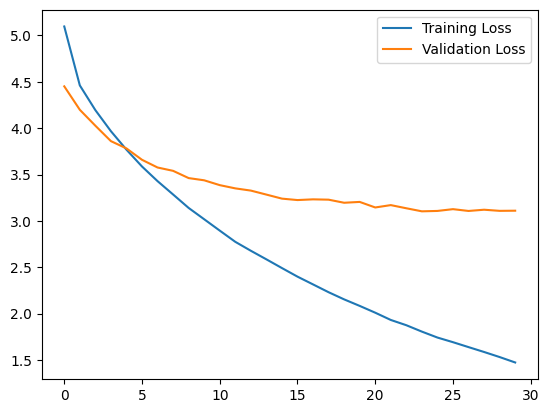

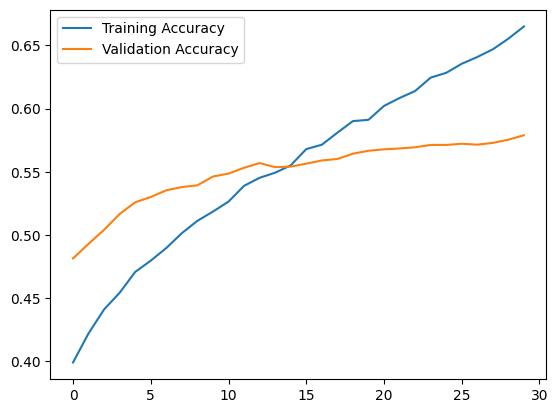

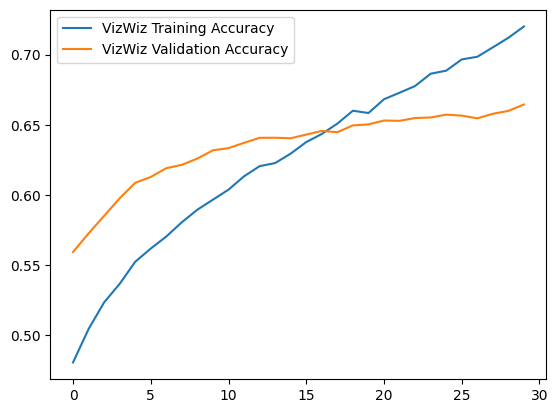

In [21]:
# Configuring training's hyperparameters for comparative analysis
NUM_EPOCHS_VQA = 30
LR = 1e-4
WEIGHT_DECAY = 1e-3
SAVE_PATH = OUTPUT_PATH

# Initializing the model
model = VQAModel(num_classes=NUM_CLASSES, device= DEVICE).to(DEVICE)

# Initializing the loss function and optimizer
loss_function = nn.CrossEntropyLoss().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay = WEIGHT_DECAY)

# Training the model and plotting the loss and accuracy
model.train_model(training_dataloader, validation_dataloader, loss_function, optimizer, epochs=NUM_EPOCHS_VQA, save_path=SAVE_PATH)
model.plot_loss()
model.plot_accuracy()
model.plot_vizwiz_accuracy()

## Building The AP Model's Architecture

In [22]:
class APModel(nn.Module):

    def __init__(self, hidden_size=512, dropout_rate=0.5, FT=False, device = torch.device("cpu")):
        
        super(APModel, self).__init__()
        
        self.training_losses = []
        self.validation_losses = []
        
        self.training_answerability = []
        self.validation_answerability = []
        
        self.device = device
        self.FT = FT
        
        # Initializing Binary Cross Entropy Loss which will be used to train the model on answerability
        self.answerability_loss_fn = nn.BCELoss()

        # First linear layer
        self.linear_layer1 = nn.Sequential(
            nn.LayerNorm(1024 + 1024),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1024 + 1024, hidden_size)
        )

        # Second linear layer
        self.linear_layer2 = nn.Sequential(
            nn.LayerNorm(hidden_size),
            # nn.Dropout(p=0.5),
            nn.Linear(hidden_size, 1) 
        )

        self.answerability_sigmoid = nn.Sigmoid()

    def forward(self, image, question):
        # Concatenating the image and question features
        features = torch.cat((image, question), dim=1)
        
        # Passing the features through the first linear layer
        features = self.linear_layer1(features)
        # Passing the features through the second linear layer
        output = self.linear_layer2(features)
        output = self.answerability_sigmoid(output)
        output = output.squeeze()
        
        return output

    def train_model(self, training_dataloader, validation_dataloader, optimizer, epochs = 10, save_path = None):
        for epoch in range(1,epochs+1):
            training_loss, train_answerability_score = self.training_step(training_dataloader, optimizer, self.device)

            if self.FT == False or epoch == epochs:
                validation_loss, validation_answerability_score = self.validation_step(validation_dataloader, self.device)
                self.validation_losses.append(validation_loss)
                self.validation_answerability.append(validation_answerability_score)

                self.training_losses.append(training_loss) 
                self.training_answerability.append(train_answerability_score)
                
            if self.FT == False:
                print(f"Epoch: {epoch} | Training Loss: {training_loss:.3f} | Validation Loss: {validation_loss:.3f}")
                print(f"Epoch: {epoch} | Training Answerability Score: {train_answerability_score:.3f} | Validation Answerability Score: {validation_answerability_score:.3f}\n")
            
                if save_path != None and epoch == epochs:
                    self.save_model(save_path + "ap_epoch_{}.pth".format(epoch))
            else:
                print(f"Epoch: {epoch}")
                
        if self.FT == True:
            return self.validation_answerability[-1]
            
        return

    def training_step(self, dataloader, optimizer, device):
        training_loss = 0.0
        answerable_true = []
        answerable_predicted = []
        self.train()
        for _, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
            image, question, answer, answer_type, answers_for_questions, answerable = batch
            image, question, answer, answer_type, answers_for_questions, answerable = image.to(device), question.to(device), answer.to(device), answer_type.to(device), answers_for_questions.to(device), answerable.to(device)
            optimizer.zero_grad()
            answerable_predict = self.forward(image, question)
            loss = self.answerability_loss_fn(answerable_predict, answerable)
            loss.backward()
            optimizer.step()
            training_loss += loss.item()
            for i in range(len(answer)):
                answerable_true.append(answerable[i].item())
                answerable_predicted.append(answerable_predict[i].item())

        answerable_true = np.array(answerable_true)
        answerable_predicted = np.array(answerable_predicted)
        training_loss /= len(dataloader)
        
        return training_loss, average_precision_score(answerable_true, answerable_predicted, average = 'weighted')
        
    def validation_step(self, dataloader, device):
        validation_loss = 0.0
        answerable_true = []
        answerable_predicted = []
        self.eval()
        with torch.no_grad():
            for _, batch in tqdm(enumerate(dataloader), total=len(dataloader)):
                image, question, answer, answer_type, answers_for_questions, answerable = batch
                image, question, answer, answer_type, answers_for_questions, answerable = image.to(device), question.to(device), answer.to(device), answer_type.to(device), answers_for_questions.to(device), answerable.to(device)
                answerable_predict = self.forward(image, question)
                loss = self.answerability_loss_fn(answerable_predict, answerable)
                validation_loss += loss.item()
                for i in range(len(answer)):
                    answerable_true.append(answerable[i].item())
                    answerable_predicted.append(answerable_predict[i].item())
                    
        answerable_true = np.array(answerable_true)
        answerable_predicted = np.array(answerable_predicted)
        validation_loss /= len(dataloader)
        
        # We will use weighted average since that there is imbalance in answerability in the dataset as displayed in EDA section
        return validation_loss, average_precision_score(answerable_true, answerable_predicted, average = 'weighted')
        
    def save_model(self, path):
        """
        Saves the model state dictionary to the given path.

        Args:
        - self: the model object
        - path (str): the path to save the model state dictionary

        Returns:
        - None
        """
        torch.save(self.state_dict(), path)

    def load_model(self, path):
        """
        Loads the model state dictionary from the given path.

        Args:
        - self: the model object
        - path (str): the path to load the model state dictionary

        Returns:
        - self: the loaded model object
        """
        self.load_state_dict(torch.load(path))
        self.eval()
        return self

    def predict(self, image, question):
        """
        Predicts the output and answer type for the given image and question.

        Args:
        - self: the model object
        - image (tensor): the image tensor
        - question (tensor): the question tensor

        Returns:
        - output (tensor): the predicted output tensor
        """
        output = self.forward(image, question)
        return output

    def plot_loss(self):
        """
        Plots the training and validation losses.

        Args:
        - self: the model object

        Returns:
        - None
        """
        plt.plot(self.training_losses, label = "Training Loss")
        plt.plot(self.validation_losses, label = "Validation Loss")
        plt.legend()
        plt.show()

    def plot_answerability(self):
        """
        Plots the training and validation answerabilities.

        Args:
        - self: the model object

        Returns:
        - None
        """
        plt.plot(self.training_answerability, label = "Training Answerability")
        plt.plot(self.validation_answerability, label = "Validation Answerability")
        plt.legend()
        plt.show()

## Training the AP Model

  0%|          | 0/642 [00:00<?, ?it/s]

  0%|          | 0/135 [00:00<?, ?it/s]

Epoch: 1 | Training Loss: 0.422 | Validation Loss: 0.411
Epoch: 1 | Training Answerability Score: 0.932 | Validation Answerability Score: 0.936



  0%|          | 0/642 [00:00<?, ?it/s]

  0%|          | 0/135 [00:00<?, ?it/s]

...

  0%|          | 0/135 [00:00<?, ?it/s]

Epoch: 49 | Training Loss: 0.326 | Validation Loss: 0.380
Epoch: 49 | Training Answerability Score: 0.968 | Validation Answerability Score: 0.948



  0%|          | 0/642 [00:00<?, ?it/s]

  0%|          | 0/135 [00:00<?, ?it/s]

Epoch: 50 | Training Loss: 0.321 | Validation Loss: 0.381
Epoch: 50 | Training Answerability Score: 0.969 | Validation Answerability Score: 0.949



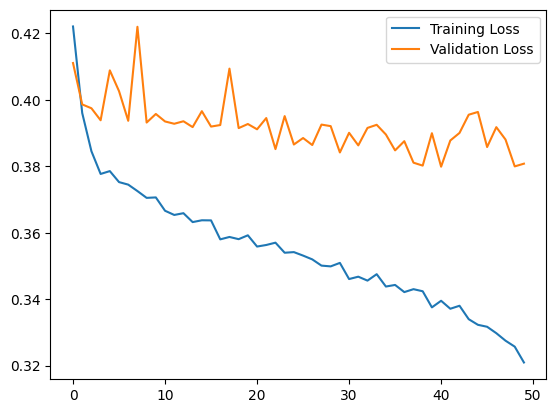

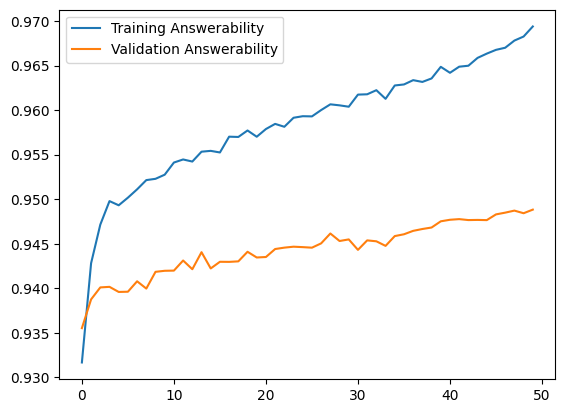

In [23]:
# Configuring training's hyperparameters for comparative analysis
NUM_EPOCHS_AP = 50
LR = 1e-4

WEIGHT_DECAY = 0
SAVE_PATH = OUTPUT_PATH

# Initializing the model
ap_model = APModel(device= DEVICE).to(DEVICE)

# Initializing the optimizer
ap_optimizer = optim.Adam(ap_model.parameters(), lr=LR, weight_decay = WEIGHT_DECAY)

# Training the model and plotting the loss and accuracy
ap_model.train_model(training_dataloader, validation_dataloader, ap_optimizer, epochs=NUM_EPOCHS_AP, save_path=SAVE_PATH)
ap_model.plot_loss()
ap_model.plot_answerability()

## Inference (Testing split)

In [24]:
class VizWizTestDataset(Dataset):
    def __init__(self, dataframe, images_features, questions_features):
        
        super(VizWizTestDataset, self).__init__()

        # Saving image & question embeddings
        self.images_features = images_features
        self.questions_features = questions_features

        # Saving the dataframe and answer encoder
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        return self.images_features[index], self.questions_features[index], self.dataframe.iloc[index].image

In [25]:
# Constructing the test dataloader
test_dataset = VizWizTestDataset(test_df, test_images, test_questions)
test_dataloader = DataLoader(test_dataset, batch_size=1)

### Inference for the VQA Model

In [26]:
# epoch = vqa_best_params['num_epochs']
epoch = NUM_EPOCHS_VQA
# model = VQAModel(num_classes=NUM_CLASSES, device= DEVICE, dropout_rate=vqa_best_params['dropout_rate'], hidden_size=vqa_best_params['fc_layer_size']).to(DEVICE)
model = VQAModel(num_classes=NUM_CLASSES, device= DEVICE).to(DEVICE)
model.load_model(OUTPUT_PATH + "epoch_{}.pth".format(epoch))

VQAModel(
  (linear_layer1): Sequential(
    (0): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=2048, out_features=512, bias=True)
  )
  (linear_layer2): Sequential(
    (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=512, out_features=5545, bias=True)
  )
)

In [27]:
def get_all_test_inference(model, test_dataloader, device):
    """
    Obtains VQA inferences for all rows in test_dataloader

    Args:
    - model (VQAModel): the model object
    - test_dataloader (Dataloader)
    - device (torch.device)

    Returns:
    - results (json): all inferences in json format for VizWiz
    """
    results = []
    for _, batch in tqdm(enumerate(test_dataloader), total=len(test_dataloader)):
        image_features, question_features, img = batch
        image_features = image_features.to(device)
        question_features = question_features.to(device)
        img = img[0]
        output = model.predict(image_features, question_features)
        predicted_answer = torch.argmax(output)
        answer = ANSWER_CATEGORIES[predicted_answer.item()]
        results.append({
            "image": img,
            "answer": answer
        })

    with open('submission.json', 'w') as f:
        json.dump(results, f)

In [28]:
get_all_test_inference(model, test_dataloader, DEVICE)

  0%|          | 0/8000 [00:00<?, ?it/s]

In [29]:
with open('submission.json', 'r') as f:
    data = json.load(f)

In [30]:
print(len(data))

8000


VizWiz_test_00000010.jpg
10    Whats the date?
Name: question, dtype: object Ans:  unanswerable


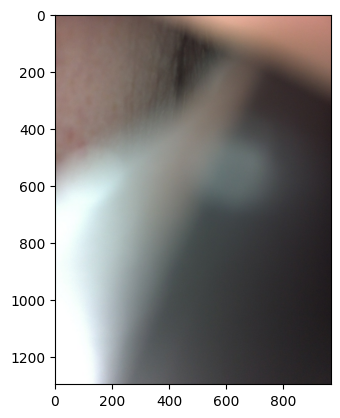

In [31]:
idx = 10
img = data[idx]['image']
print(img)
answer = data[idx]['answer']

question = test_df[test_df['image'] == img].question
img = Image.open(TEST_PATH + '/' + img)
plt.imshow(img)

print(question, "Ans: ", answer)

### Inference for the AP Model

In [32]:
# epoch = ap_best_params['num_epochs']
epoch = NUM_EPOCHS_AP
# ap_model = APModel(device= DEVICE, dropout_rate=ap_best_params['dropout_rate'], hidden_size=ap_best_params['fc_layer_size']).to(DEVICE)
ap_model = APModel(device= DEVICE).to(DEVICE)
ap_model.load_model(OUTPUT_PATH + "ap_epoch_{}.pth".format(epoch))

APModel(
  (answerability_loss_fn): BCELoss()
  (linear_layer1): Sequential(
    (0): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=2048, out_features=512, bias=True)
  )
  (linear_layer2): Sequential(
    (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=512, out_features=1, bias=True)
  )
  (answerability_sigmoid): Sigmoid()
)

In [33]:
def get_all_test_inference_ap(model, test_dataloader, device):
    """
    Obtains AP inferences for all rows in test_dataloader

    Args:
    - model (APModel): the model object
    - test_dataloader (Dataloader)
    - device (torch.device)

    Returns:
    - results (json): all inferences in json format for VizWiz
    """
    results = []
    for _, batch in tqdm(enumerate(test_dataloader), total=len(test_dataloader)):
        image_features, question_features, img = batch
        image_features = image_features.to(device)
        question_features = question_features.to(device)
        img = img[0]
        output = model.predict(image_features, question_features)
        results.append({
            "image": img,
            "answerable": output.item()
        })

    with open('ap_submission.json', 'w') as f:
        json.dump(results, f)

In [34]:
get_all_test_inference_ap(ap_model, test_dataloader, DEVICE)

  0%|          | 0/8000 [00:00<?, ?it/s]

In [35]:
with open('ap_submission.json', 'r') as f:
    ap_data = json.load(f)

In [36]:
print(len(ap_data))

8000


VizWiz_test_00000010.jpg
10    Whats the date?
Name: question, dtype: object Ans:  0.014269298873841763


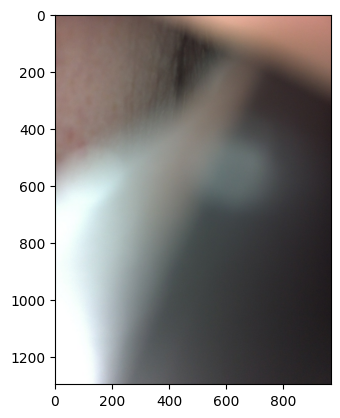

In [37]:
idx = 10
img = ap_data[idx]['image']
print(img)
answer = ap_data[idx]['answerable']

question = test_df[test_df['image'] == img].question
img = Image.open(TEST_PATH + '/' + img)
plt.imshow(img)

print(question, "Ans: ", answer)